<a href="https://colab.research.google.com/github/DACSS690C26/Homework_1/blob/main/hm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 1 DACSS690C
##Spatial Autocorrelation
##Patrick McGrath
###Summer 2026

Import and activate needed libraries and set the seed for reproducibility.

In [15]:
#Install needed Libraries
#!pip show pysal pandas geopandas libpysal esda
import geopandas as gpd
import pandas as pd
from libpysal.graph import Graph
from numpy.random import seed
seed(42)
import esda # from pysal
import matplotlib.pyplot as plt

Read Peru Map data from Github

In [16]:
#Pull needed data from GITHUB Repo
peru_link = "https://github.com/DACSS690C26/Homework_1/raw/main/PeruMaps.gpkg"
peru=gpd.read_file(peru_link,layer='good_geom')


Verify the map is projected

In [17]:
peru.crs.to_epsg(),\
peru.crs.is_projected, \
set(peru.geom_type)
#(5387, True, {'MultiPolygon'})
peru=peru.to_crs(5387)
#peru.DEPARTAMENTO.unique()#Lima not LIMA

Keep the DEPARTAMENTO of 'Lima'

In [18]:
lima=peru[peru['DEPARTAMENTO']=='Lima']
#lima.head()


Produce the LISA MAP using the normalized neighborhood  matrix (or weights matrix) using the QUEEN criterion

<Axes: >

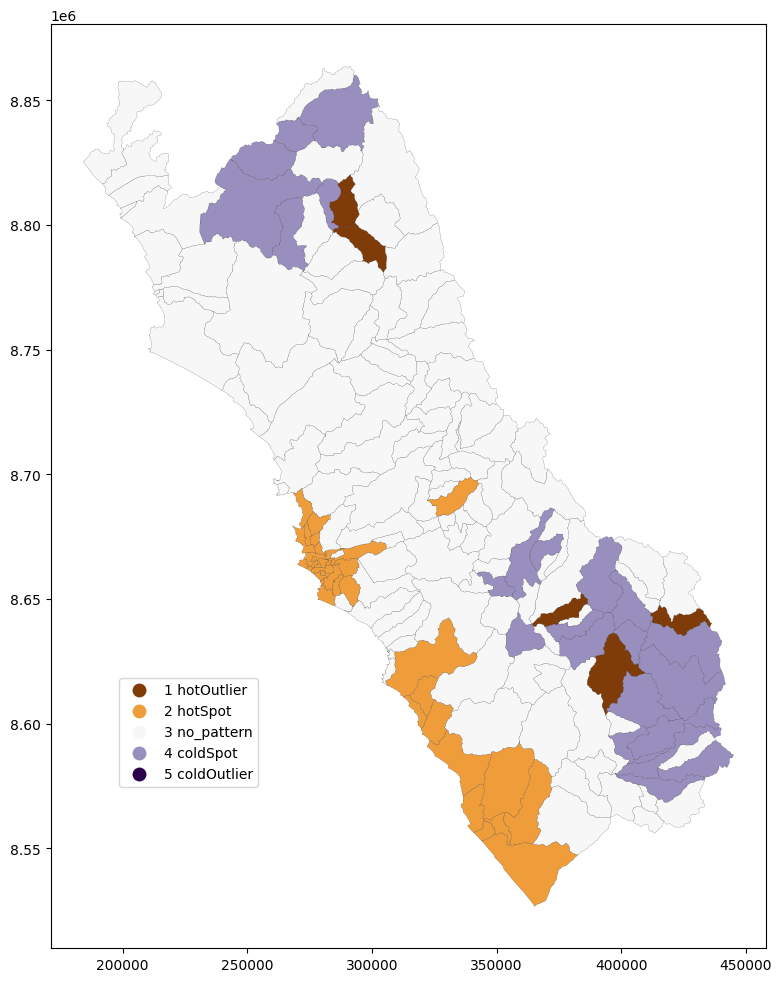

In [19]:
lima_queen=Graph.build_contiguity(lima,rook=False)

toWideMatrix=lambda g:pd.DataFrame(g.adjacency).unstack().fillna(0)

queen_lima_Matrix=toWideMatrix(lima_queen)

lima_queen=lima_queen.transform("r")

ylag = lima_queen.lag(lima["Educ_sec_comp2019_pct"])

lima=lima.assign(Educ_sec_comp2019_pct_lagged=ylag)

MoranGlobal_HS = esda.Moran(lima['Educ_sec_comp2019_pct'], lima_queen)
MoranGlobal_HS.I,MoranGlobal_HS.p_sim


lisa = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], lima_queen)


# get the quadrants
lima['Lisa_queen'] = lisa.get_cluster_labels(crit_value=0.05)


TheStats=["mean", "min", "max","var"]


# stats by the lisa cluster
grouped_stats = lima.groupby('Lisa_queen')['Educ_sec_comp2019_pct'].agg(TheStats)

# stats for the entire, ungrouped column
global_stats = lima['Educ_sec_comp2019_pct'].agg(TheStats)

# Convert 'global_stats' (Series) to a DataFrame with an appropriate index name
global_stats_df = pd.DataFrame(global_stats).T
global_stats_df.index = ['Global/Total'] # simple but key

# Combine both
pd.concat([grouped_stats, global_stats_df])


oldLabels=['Insignificant', 'Low-Low', 'High-High', 'High-Low', 'Low-High']
newLabels = ['3 no_pattern', '4 coldSpot','2 hotSpot','1 hotOutlier' , '5 coldOutlier']

labels = dict(zip(oldLabels, newLabels))

#labels
lima.replace({'Lisa_queen':labels},inplace=True)

#Weird coloring issues, changing to cats seems to fix
allCats = ['1 hotOutlier', '2 hotSpot', '3 no_pattern', '4 coldSpot', '5 coldOutlier']
lima['Lisa_queen'] = pd.Categorical(lima['Lisa_queen'], categories=allCats, ordered=True)

myColMap = plt.get_cmap('PuOr', 5)


#plot the map
lima.plot(column='Lisa_queen',
                categorical=True,
                cmap=myColMap,
                linewidth=0.1,
                edgecolor='k',
                legend=True,
                legend_kwds={'bbox_to_anchor': (0.3, 0.3)},
                figsize=(12,12))

Redo LISA Map using KNN with K as 8

Confirm that the additional columns have been successfully added to our dataframe

<Axes: >

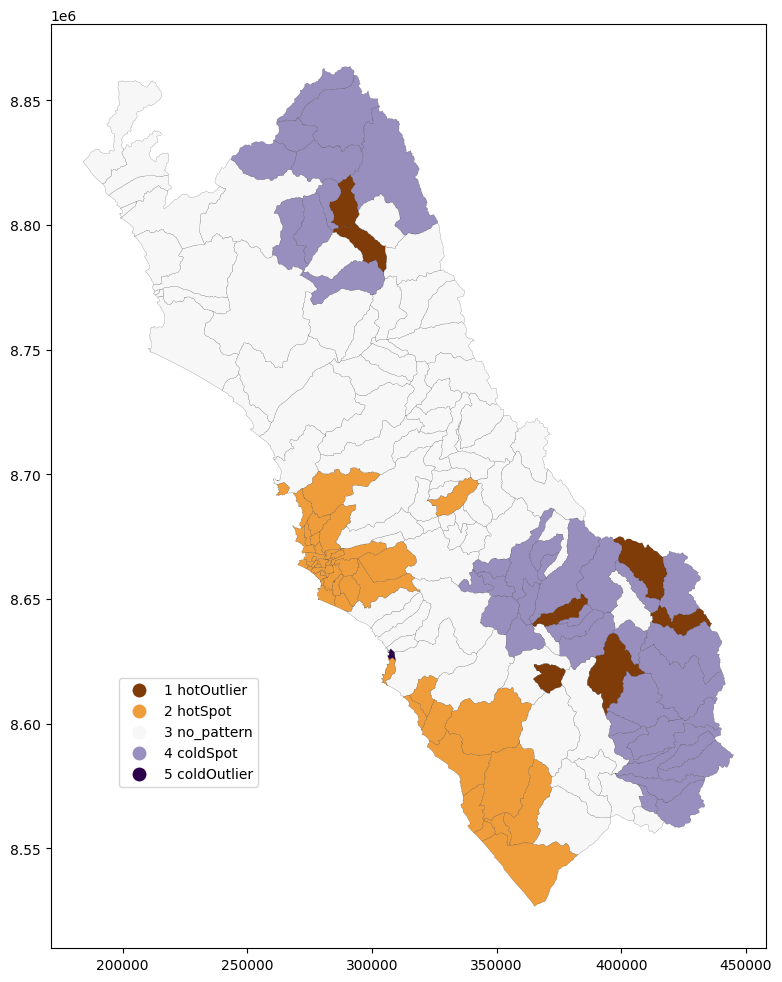

In [31]:

#LISA with KNN 8
lima_reference_points = lima.representative_point()

knn8_lima = Graph.build_knn(lima_reference_points, k=8)

#Normalize the weights
knn8_lima = knn8_lima.transform("r")

#Moran
lisa_knn8 = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], knn8_lima)

# save the labels, then rename
lima['Lisa_knn8'] = lisa_knn8.get_cluster_labels(crit_value=0.05)
lima.replace({'Lisa_knn8': labels}, inplace=True)

# plot the KNN8 LISA
lima.plot(column='Lisa_knn8',
          categorical=True,
          cmap=myColMap,
          linewidth=0.1,
          edgecolor='k',
          legend=True,
          legend_kwds={'bbox_to_anchor': (0.3, 0.3)},
          figsize=(12, 12))


In [21]:
lima.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 171 entries, 39 to 1871
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   DEPARTAMENTO                  171 non-null    object  
 1   PROVINCIA                     171 non-null    object  
 2   DISTRITO                      171 non-null    object  
 3   ubigeo                        171 non-null    object  
 4   Poblacion                     171 non-null    int64   
 5   IDH2019                       171 non-null    float64 
 6   Educ_sec_comp2019_pct         171 non-null    float64 
 7   NBI2017_pct                   171 non-null    float64 
 8   Viv_sin_serv_hig2017_pct      171 non-null    float64 
 9   geometry                      171 non-null    geometry
 10  Educ_sec_comp2019_pct_lagged  171 non-null    float64 
 11  Lisa_queen                    171 non-null    category
 12  Lisa_knn8                     171 non-null   

Compare the the results of the two criterion

In [29]:

different = lima[lima['Lisa_queen'] != lima['Lisa_knn8']]
#different.shape
print(f"{len(different)} of the districts have different values when using either Queen or KNN Criterion")



32 of the districts have different values when using either Queen or KNN Criterion
